#  Исследование результатов А/В-теста

Мы работаем с приложением, ключевая часть которого — ланта новостей, пользователи могут просматривать посты и ставить лайки, также они могут также отправлять сообщения друг другу.

Команда ML сделала новый алгоритм рекомендации новостей в ленте - показываем пользователю посты, наиболее похожие на те, которые он лайкал.  Ожидается, что новый алгоритм сделает пользователей счастливее (то есть удлинится LTV, повысятся денежные конверсии и т.д.), а продукт удобнее/приятнее в использовании.

Чтобы разобраться, команда решила провести A/B-эксперимент. 

### А/В-эксперимент

В эксперименте участвовали старые пользователи, тест запускали с 03-04-2026 по 09-04-2026. 
Пользователей случайным образом разделили на две равные группы: 
- Контрольная группа видела прежний алгоритм рекомендации.
- Тестовой группе показывали посты, наиболее похожие на те, которые они лайкали. 

После разделения активность пользователей анализировали в течение недели.

Цель эксперимента — оценить, как новый алгоритм рекомендации новостей в ленте влияет на поведение пользователей и их дальнейшую вовлеченность.

При внедрении новой фичи команда продукта выдвинула такие гипотезы:
- Гипотеза роста: новый алгоритм рекомендации новостей в ленте будет позволит показывать пользователям более интересные и актуальные посты, что повысит вовлеченность пользователей в продукт.

Для эксперимента выбрали следующую метрику: 
- Ключевая метрика — CTR из просмотров в лайки.

Ожидалось, что ключевая метрика покажет значительный рост.  

#### 1. Анализ исторических данных A/A-тест

Убедимся в том, что наша система сплитования работает корректно:
- Проведем A/A-тест на исторических данных с '2026-03-27' по '2026-04-02', изучим распределение p-value в синтетическом тесте. 

#### 2. Анализ данных А/В-теста

Изучение результатов эксперимента будет состоять из четырех этапов:  
- Изучим распределение CTR в группах.
- Оценим статитическую значимость изменений в тестовой и контрольной группе с помощью тест Манна-Уитни.
- Оценим статитическую значимость изменений в тестовой и контрольной группе с помощью бутсрепа.
- Сравним  t-тестом отличия между группами 1 и 2 по метрике линеаризованных лайков.

### Данные

Будем работать с таблицей:  

1. Таблица `{db}.feed_actions` содержит данные о ключевых действиях пользователей и информацию о них, привлечённых в период с момента запуска приложения по настоящее время. 

Общие поля датасетов:
- `user_id` — уникальный идентификатор пользователя;
- `post_id` — уникальный идентификатор поста;
- `action` — действие пользователя: `view` — просмотр, `like` — лайк;
- `time` — время действия в системе;
- `gender` — пол пользователя;
- `age` — возраст пользователя;
- `country` — страна;
- `city` — город;
- `os` — операционная система; 
- `source` — канал привлечения: `ads` — рекламный, `organic` — органический;
- `exp_group` — группа пользователя в эксперименте.

### План проекта
1. Загрузка исторических данных и их предобработка и проведение A/A-теста;
2. Оценка статитической значимости изменений в тестовой и контрольной группе с помощью тест Манна-Уитни;
3. Оценка статитической значимости изменений в тестовой и контрольной группе с помощью бутсрепа;
4. Сравнение t-тестом отличия между тестовой и контрольной группой по метрике линеаризованных лайков;
5. Сегментый анализ тестовой группы.

In [1]:
import pandas as pd
import pandahouse
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from scipy.stats import mannwhitneyu
from scipy.stats import ttest_ind

In [2]:
# Параметры подключения
connection = {
    'host': 'http://clickhouse.lab.karpov.courses:8123',
    'password': 'dpo_python_2020',
    'user': 'student',
    'database': 'simulator_20260420'
}

## А/А-тест

-  Изначально проведем А/А-тест, чтобы убедиться в том, что наша система сплитования работает корректно.  

1) Берём данные АА-теста из следующего диапазона: с '2026-03-27' по '2026-04-02';
2) Из групп 2 и 3 берём подвыборки без возвращения размером в 500 юзеров;
3) Сравним их t-тестом и сохраним p-value 1000 раз.
4) Рисуем гистограмму получившихся p-value и посчитайте долю p-value, оказавшихся ниже порога значимости в 0.05. 

In [3]:
# Запрос для выгрузки данных для группы 2 и 3
q = """
SELECT exp_group, 
    user_id,
    sum(action = 'like') as likes,
    sum(action = 'view') as views,
    likes/views as ctr
FROM {db}.feed_actions 
WHERE toDate(time) between '2026-03-27' and '2026-04-02'
    and exp_group in (2,3)
GROUP BY exp_group, 
    user_id    
"""

In [4]:
# Загрузка данных в датафрейм
df = pandahouse.read_clickhouse(q, connection=connection)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16787 entries, 0 to 16786
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   exp_group  16787 non-null  int8   
 1   user_id    16787 non-null  uint32 
 2   likes      16787 non-null  uint64 
 3   views      16787 non-null  uint64 
 4   ctr        16787 non-null  float64
dtypes: float64(1), int8(1), uint32(1), uint64(2)
memory usage: 475.5 KB


In [6]:
# Списки для хранения p-value
p_values = []

In [7]:
# Цикл для 10000 иттераций по группам 2 и 3
for i in range(10000):
    sample2 = df[df['exp_group'] == 2]['ctr'].sample(n=500, replace=False)
    sample3 = df[df['exp_group'] == 3]['ctr'].sample(n=500, replace=False)

    i, p_value = stats.ttest_ind(sample2, sample3, equal_var=False)
    
    p_values.append(p_value) 

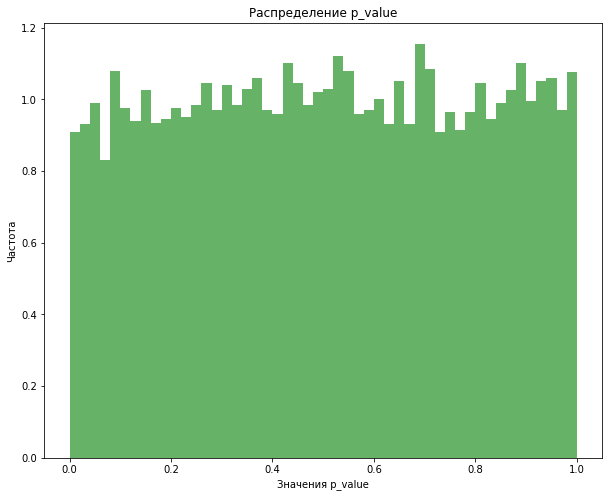

In [8]:
# Изобразим распределение p-value
plt.figure(figsize=(10, 8))

plt.hist(p_values, bins=50, density=True, alpha=0.6, color='green')

plt.xlabel('Значения p_value')
plt.ylabel('Частота')
plt.title('Распределение p_value')

plt.show()

In [9]:
# Рассчет среднего p-value и доли p-value < 0.05
print(f"Среднее p-value: {round(np.mean(p_values), 2)}")
print(f"Доля p-value < 0.05: {np.mean(np.array(p_values) < 0.05)}")

Среднее p-value: 0.51
Доля p-value < 0.05: 0.0462


#### Вывод: 
Распределение получившихся p-value является примерно равномерным. Доля p-value ниже порога значимости составляет около 0.05, значит, система сплитования работает корректно.

## A/В-тест

1) Берём данные А/B-теста из следующего диапазона: с '2026-04-03' по '2026-04-09';
2) Для анализа берем группы 1 - в качестве контрольной, 2 - в качестве тестовой;
3) Изучим распределение CTR в группах.
4) Оценим статитическую значимость изменений в тестовой и контрольнйо группе с помощью тест Манна-Уитни и бутсрепа.
5) Сравним  t-тестом отличия между группами 1 и 2 по метрике линеаризованных лайков.

In [10]:
# Запрос для выгрузки данных для группы 1 и 2
q_AB = """
SELECT exp_group, 
    user_id,
    sum(action = 'like')/sum(action = 'view') as ctr, 
    sum(action = 'like') - (SELECT sum(action = 'like')/sum(action = 'view') as ctr_control
                            FROM {db}.feed_actions 
                            WHERE toDate(time) between '2026-03-27' and '2026-04-02'
                            and exp_group = 0) * sum(action = 'view') as linearized_ctr                       
FROM {db}.feed_actions 
WHERE toDate(time) between '2026-04-03' and '2026-04-09'
    and exp_group in (1,2)
GROUP BY exp_group, 
    user_id    
"""

In [11]:
# Загрузим данные в датафрейм
df_AB = pandahouse.read_clickhouse(q_AB, connection=connection)

df_AB.head()

,exp_group,user_id,ctr,linearized_ctr
0,1,109963,0.200000,-0.178056
1,1,26117,0.226950,2.126272
2,1,138232,0.246575,2.533460
3,1,26295,0.276596,9.126272
4,1,18392,0.218750,0.220147


In [12]:
# Прверим уникальность пользователей в группах 1 и 2
users_1 = df_AB[df_AB['exp_group'] == 1]['user_id']
users_2 = df_AB[df_AB['exp_group'] == 2]['user_id']

users_1_and_2 = list(set(users_1)&set(users_2))

print(f'Количество пользователей, которые встречаются одновременно в группах A и B : {len(users_1_and_2)}, значит группы независимы.')

Количество пользователей, которые встречаются одновременно в группах A и B : 0, значит группы независимы.


In [13]:
# Выгрузим данные по CTR и CTR с линеаризацией
df_AB_1 = df_AB[df_AB['exp_group'] == 1]['ctr']
df_AB_2 = df_AB[df_AB['exp_group'] == 2]['ctr']

AB_1_linearized = df_AB[df_AB['exp_group'] == 1]['linearized_ctr']
AB_2_linearized = df_AB[df_AB['exp_group'] == 2]['linearized_ctr']

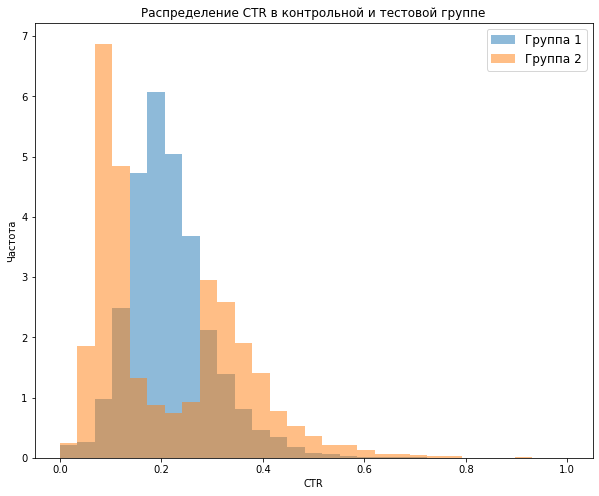

In [14]:
# Визуализируем распределение метрики в группах при помощи гистрограммы
plt.figure(figsize=(10, 8))
bins = np.linspace(0, 1, 30)

plt.hist(df_AB_1, alpha=0.5, bins = bins, density=True, label='Группа 1')
plt.hist(df_AB_2, alpha=0.5, bins = bins, density=True, label='Группа 2')

plt.title('Распределение CTR в контрольной и тестовой группе')
plt.xlabel('CTR')
plt.ylabel('Частота')
plt.legend(fontsize='large')

In [15]:
# Выгрузим данные CTR по группах отдельно 
data = {'Группа 1': df_AB_1.reset_index(drop=True),
        'Группа 2': df_AB_2.reset_index(drop=True)}

data = pd.DataFrame(data)
data.head()

,Группа 1,Группа 2
0,0.200000,0.083333
1,0.226950,0.080460
2,0.246575,0.108911
3,0.276596,0.295455
4,0.218750,0.444444


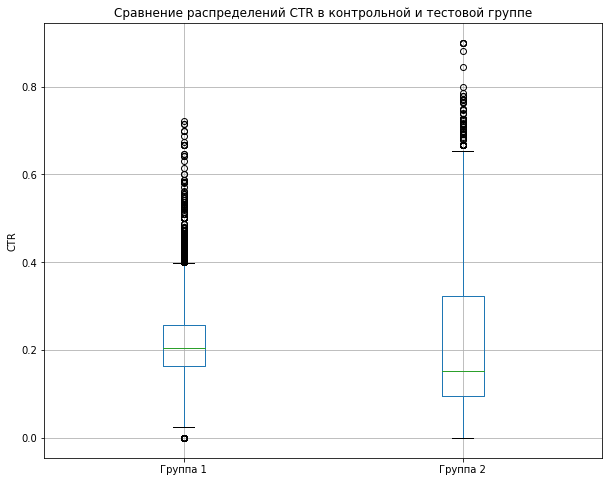

In [16]:
# Визуализируем распределение метрики в группах при помощи ящика с усами
plt.figure(figsize=(10, 8))  
data.boxplot()

plt.title("Сравнение распределений CTR в контрольной и тестовой группе")
plt.ylabel("CTR")
plt.grid(True)
plt.show()

In [36]:
ctr_1 = df_AB[df_AB['exp_group'] == 1]['ctr'].median()
ctr_2 = df_AB[df_AB['exp_group'] == 2]['ctr'].median()
rel_delta = round((ctr_2-ctr_1)/ctr_1*100, 2)

print(f'CTR в контрольной группе - {round(ctr_1, 4)}, в тестовой - {round(ctr_2, 4)}, относительное изменение {rel_delta}%')

CTR в контрольной группе - 0.2059, в тестовой - 0.1533, относительное изменение -25.55%


#### Вывод:  
В группе 1 более высокий медианный CTR, при этом Группа 2 демонстрирует больший разброс и наличие сегмента пользователей с аномально высокой кликабельностью. В обеих группах распределение не является нормальным из-за длинных «хвостов» справа, поэтому использование среднего не даст в данном случае достоверной оценки.

## Тест Манна-Уитни

Гипотезы для проверки:
  - Распределение CTR в контрольной и тестовой группы не различается.
    H<sub>0</sub>: p<sub>control</sub> = p<sub>test</sub>
  - Распределение CTR в контрольной и тестовой группы различается.
    H<sub>1</sub>: p<sub>control</sub> ~~=~~ p<sub>test</sub> 

In [18]:
alpha = 0.05
mw_test = mannwhitneyu(
    df_AB_1, 
    df_AB_2
)

if mw_test.pvalue > alpha:
    print(f'pvalue={mw_test.pvalue} > {alpha}')
    print('Нулевая гипотеза находит подтверждение! Распределение CTR в контрольной и тестовой группы не различается.')
else:
    print(f'pvalue={mw_test.pvalue} < {alpha}')
    print('Нулевая гипотеза не находит подтверждения! Распределение CTR в в контрольной и тестовой группы различается.')

pvalue=4.632205841806026e-45 < 0.05
Нулевая гипотеза не находит подтверждения! Распределение CTR в в контрольной и тестовой группы различается.


### 4. Анализ изменений суммы депозитов на платящего пользователя

Используя бутстрап, сравним разницы перцентилей (25, 50, 75) CTR в контрольной и тестовой группах.

25-й перцентиль контрольной группы: 0.16
25-й перцентиль тестовой группы: 0.10
95%-й доверительный интервал разности 25-х перцентилей [-0.07, -0.06]



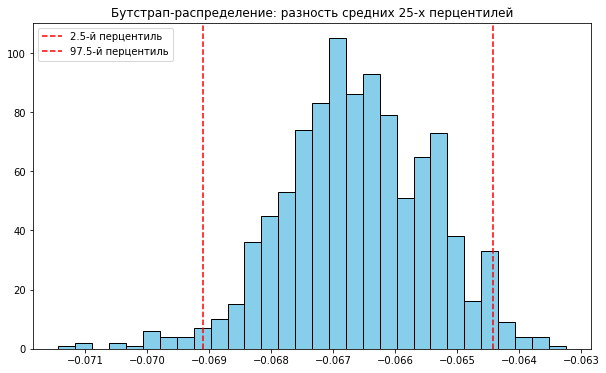

50-й перцентиль контрольной группы: 0.21
50-й перцентиль тестовой группы: 0.15
95%-й доверительный интервал разности 50-х перцентилей [-0.06, -0.05]



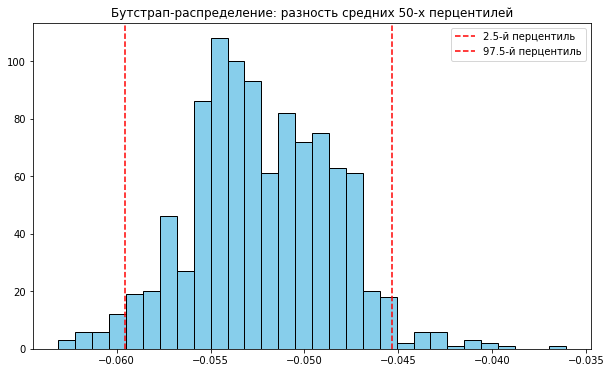

75-й перцентиль контрольной группы: 0.26
75-й перцентиль тестовой группы: 0.32
95%-й доверительный интервал разности 75-х перцентилей [0.06, 0.07]



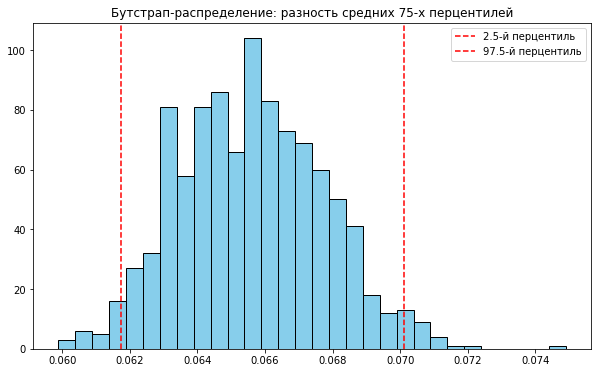

In [19]:
# Проводим исследование изменения метрик с помощью бустрап
for j in [25, 50, 75]:
    n_iterations = 1000
    boot_diffs = []
    for i in range(n_iterations):
        boot_control = np.random.choice(df_AB_1, size=len(df_AB_1), replace=True)
        boot_test = np.random.choice(df_AB_2, size=len(df_AB_2), replace=True)

        # Для расчёта перцентиля используем .percentile() из библиотеки numpy 
        control_p = np.percentile(boot_control, j)
        test_p = np.percentile(boot_test, j)

        # Находим разницу между значениями тестовой и контрольной групп
        boot_diffs.append(test_p - control_p)
    
    # Создаём массив разниц между перцентилями тестовой и контрольной групп
    boot_diffs = np.array(boot_diffs)

    # Доверительный интервал разницы между 95-ми перцентилями (перцентильный метод)
    diff_ci = np.percentile(boot_diffs, [2.5, 97.5])

    # Вывод доверительного интервала
    print(f"{j}-й перцентиль контрольной группы: {np.percentile(df_AB_1, j):.2f}")
    print(f"{j}-й перцентиль тестовой группы: {np.percentile(df_AB_2, j):.2f}")
    print(f"95%-й доверительный интервал разности {j}-х перцентилей [{diff_ci[0]:.2f}, {diff_ci[1]:.2f}]\n")  
    
    # Визуализация
    plt.figure(figsize=(10, 6))
    plt.hist(boot_diffs, bins=30, color='skyblue', edgecolor='black')
    plt.axvline(diff_ci[0], color='red', linestyle='--', label='2.5-й перцентиль')
    plt.axvline(diff_ci[1], color='red', linestyle='--', label='97.5-й перцентиль')
    plt.title(f"Бутстрап-распределение: разность средних {j}-х перцентилей")
    plt.legend()
    plt.show()

#### Вывод:
- Новый алгоритм рекомендации постов привел к тому, что 25-ый перцентиль в тестовой группе снизился на 6 единиц, доверительный интервал для разности (test − control) лежит ниже нуля, что указывает на статистически значимое различие CTR.
- 50-ый перцентиль также снизился на 6 единиц, это статистически значимое снижение, так как доверительный интервал для разности лежит ниже нуля.
- Доверительный интервал разности 75-х перцентилей демонстрирует наличие статистически значимого изменения CTR в тестовой группе - увеличение на 6 единиц.

## t-тест с линеаризацией

Гипотезы для проверки:
  - Средний CTR в контрольной и тестовой группы не различается.
    H<sub>0</sub>: CTR<sub>control</sub> = CTR<sub>test</sub>
  - Средний CTR в контрольной и тестовой группы различается.
    H<sub>1</sub>: CTR<sub>control</sub> ~~=~~ CTR<sub>test</sub> 

In [20]:
# Исследуем изменение линеаризованного CTR в тестовой и контрольной
alpha = 0.05 

stat_ttest, p_value_ttest = ttest_ind(
    AB_1_linearized, 
    AB_2_linearized 
) 

if p_value_ttest>alpha:
    print(f'p-value теста Стьюдента с линеаризацией = {round(p_value_ttest, 10)}')
    print('Нулевая гипотеза находит подтверждение!')
    print('Интерпретация: CTR в контрольной и тестовой группах одинаковы')
else:
    print(f'p-value теста Стьюдента с линеаризацией ={round(p_value_ttest, 10)}')
    print('Нулевая гипотеза не находит подтверждения!')
    print('Интерпретация: CTR в контрольной и тестовой группах не одинаковы')

p-value теста Стьюдента с линеаризацией =2.8e-09
Нулевая гипотеза не находит подтверждения!
Интерпретация: CTR в контрольной и тестовой группах не одинаковы


## Сегментый анализ тестовой группы

В тестовой группе наблюдается двугорбое распределение CTR, при этом один горб смещен в область меньших значений, по сравнению с пиком контрольной группы, другой в область необычно высоких значений CTR. Проведем сегментный анализ, чтобы проверить, не дают ли определенный сегменты смещение как в большую, так и в меньшую сторону.

In [21]:
# Выделим данные CTR для тестовой группы
df_2_type = df_AB[df_AB['exp_group'] == 2][['user_id', 'ctr']]

In [22]:
# Определим верхнюю границу ящика с усами для значений CTR во второй группе
q1 = np.percentile(df_2_type['ctr'], 25)
q3 = np.percentile(df_2_type['ctr'], 75)
iqr = q3 - q1

upper_whisker = q3 + 1.5*iqr

In [23]:
# Разделим пользователей на активных и неактивных по значению CTR относительное верхней границы выбросов 
df_2_type['type_of_user'] = np.where(df_2_type['ctr'] > upper_whisker, 'Активный', 'Неактивный')

df_2_type.head()

,user_id,ctr,type_of_user
5,131473,0.083333,Неактивный
6,23985,0.080460,Неактивный
7,24523,0.108911,Неактивный
8,32420,0.295455,Неактивный
9,24239,0.444444,Неактивный


In [24]:
# Выделим данные CTR для тестовой группы
q_2 = """
SELECT DISTINCT user_id, gender, age, country, city, os, source, 
  multiIf(age <= 18, 'Подростки',
     age <= 25, 'Юные',
     age <= 40, 'Молодые',
     age <= 60, 'Зрелые',
     'Пожилые') age_group
FROM {db}.feed_actions 
WHERE exp_group = 2    
"""

In [25]:
df_2 = pandahouse.read_clickhouse(q_2, connection=connection)

In [26]:
# Объединим данные CTR с характеристиками пользователей 
df_2 = df_2.merge(df_2_type[['user_id', 'type_of_user']], on = 'user_id')

In [27]:
df_2.head()

,user_id,gender,age,country,city,os,source,age_group,type_of_user
0,122553,1,42,Russia,Perm,Android,organic,Зрелые,Неактивный
1,23590,1,18,Russia,Moscow,iOS,ads,Подростки,Неактивный
2,27049,1,26,Russia,Chelyabinsk,Android,ads,Молодые,Неактивный
3,119503,1,35,Russia,Shlisselburg,iOS,organic,Молодые,Неактивный
4,18200,1,45,Azerbaijan,Baku,Android,ads,Зрелые,Неактивный


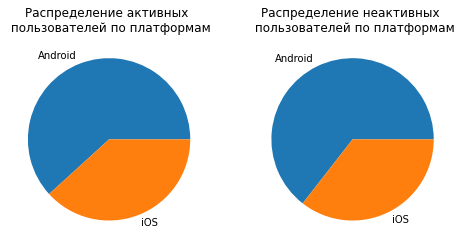

In [28]:
# Исследуем распределение активных и неакцтивных пользователей по платформам
df_os_active = df_2[df_2['type_of_user'] == 'Активный'].groupby('os')\
    ['user_id'].count().reset_index(name='count_of_users')
df_os_nonactive = df_2[df_2['type_of_user'] == 'Неактивный'].groupby('os')\
    ['user_id'].count().reset_index(name='count_of_users')

plt.figure(figsize=(8, 8))

plt.subplot(1, 2, 1)
plt.pie(df_os_active['count_of_users'], labels = df_os_active['os'])
plt.title("Распределение активных \n пользователей по платформам")

plt.subplot(1, 2, 2)
plt.pie(df_os_nonactive['count_of_users'], labels = df_os_nonactive['os'])
plt.title("Распределение неактивных \n пользователей по платформам")

plt.show()

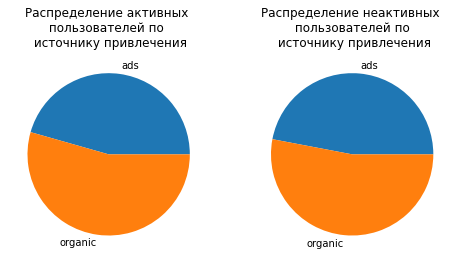

In [29]:
# Исследуем распределение активных и неакцтивных пользователей по каналам привлечения
df_source_active = df_2[df_2['type_of_user'] == 'Активный'].groupby('source')\
    ['user_id'].count().reset_index(name='count_of_users')
df_source_nonactive = df_2[df_2['type_of_user'] == 'Неактивный'].groupby('source')\
    ['user_id'].count().reset_index(name='count_of_users')

plt.figure(figsize=(8, 8))

plt.subplot(1, 2, 1)
plt.pie(df_source_active['count_of_users'], labels = df_source_active['source'])
plt.title("Распределение активных \n пользователей по  \n источнику привлечения")

plt.subplot(1, 2, 2)
plt.pie(df_source_nonactive['count_of_users'], labels = df_source_nonactive['source'])
plt.title("Распределение неактивных \n пользователей по \n источнику привлечения")

plt.show()

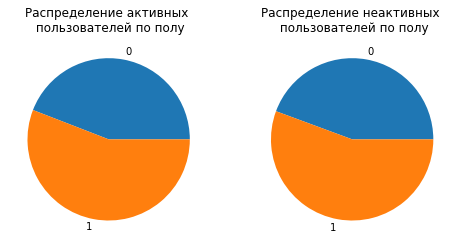

In [30]:
# Исследуем распределение активных и неакцтивных пользователей по полу
df_gender_active = df_2[df_2['type_of_user'] == 'Активный'].groupby('gender')\
    ['user_id'].count().reset_index(name='count_of_users')
df_gender_nonactive = df_2[df_2['type_of_user'] == 'Неактивный'].groupby('gender')\
    ['user_id'].count().reset_index(name='count_of_users')

plt.figure(figsize=(8, 8))

plt.subplot(1, 2, 1)
plt.pie(df_gender_active['count_of_users'], labels = df_gender_active['gender'])
plt.title("Распределение активных \n пользователей по полу")

plt.subplot(1, 2, 2)
plt.pie(df_gender_nonactive['count_of_users'], labels = df_gender_nonactive['gender'])
plt.title("Распределение неактивных \n пользователей по полу")

plt.show()

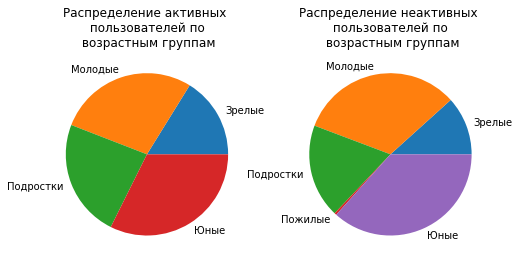

In [31]:
# Исследуем распределение активных и неакцтивных пользователей по возрастным группам
df_age_active = df_2[df_2['type_of_user'] == 'Активный'].groupby('age_group')\
    ['user_id'].count().reset_index(name='count_of_users')
df_age_nonactive = df_2[df_2['type_of_user'] == 'Неактивный'].groupby('age_group')\
    ['user_id'].count().reset_index(name='count_of_users')

plt.figure(figsize=(8, 8))

plt.subplot(1, 2, 1)
plt.pie(df_age_active['count_of_users'], labels = df_age_active['age_group'])
plt.title("Распределение активных \n пользователей по \n возрастным группам")

plt.subplot(1, 2, 2)
plt.pie(df_age_nonactive['count_of_users'], labels = df_age_nonactive['age_group'])
plt.title("Распределение неактивных \n пользователей по \n возрастным группам")

plt.show()

#### Выводы   
- При сегментном анализе по платформам, каналу привлечения, полу пользователей не выявленно различий в распределении среди активных и неактивных пользователей.
- При рассмотрении возрастных категорий заметно некоторое различие среди активных и неактивных пользователей, однако, не объясняет наличие сегмента пользователей с аномально высоким CTR.

### Выводы   

- В контрольной группе более высокий 25%-й и медианный CTR, эти изменения статистически значимы, при этом тестовая группа демонстрирует больший разброс и статистически значимое смещение 75%-го перцентиля в большую область, а также наличие сегмента пользователей с аномально высокой кликабельностью.
- Теста Манна-Уитни подтверждает, что распределения в контрольной и тестовой группе не совпадают.
- Можно предположить, что пользователи, предпочитающие и любящие узкую тему, получают качественный контент, что резко повышает их вовлеченность,  в то время как другая часть тестовой группы  испытывают недостаток разнообразия, благодаря новой системе рекомендаций, что понижает их вовлеченность.
- При сегментном анализе не выявленно различий в распределении среди активных и неактивных пользователей.

### Рекомендации

- Вводить новый алгоритм рекомендации не рекомендуется, так как наблюдается падение медианного CTR, то есть удержание среднестатистического пользователя снижается, а для пользователей, демонстрирующих аномально высокую вовлеченность нельзя гарантировать стаблильное увеличение CTR, однотипный контент может вызвать временный всплеск интереса, который угаснет через некоторое время.
- Пересмотреть принцип алгоритмы рекомендаци, увеличить время теста до двух недель, чтобы снизить риск обнаружить увеличение вовлеченности в большей степени из-за эффекта новизны.